In [4]:
# ==========================================
# CELL 1: Imports & Data Loading
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load the dataset (Make sure file is in the same directory or update path)
# URL: https://docs.google.com/spreadsheets/d/1aDiNQMStFPyY7mJEgt2sIAApFrG2uE19
df = pd.read_csv('ABC_Employee.csv') # Or pd.read_excel('myexcel.xlsx') depending on your format

print("Dataset Overview:")
print(df.info())
df.head()

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB
None


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [5]:
# ==========================================
# CELL 2: Preprocessing Data Integrity
# ==========================================
# 1. Height Replacement: Assign random integers between 150 and 180
np.random.seed(42)  # For reproducible results
df['Height'] = np.random.randint(150, 181, size=len(df))

# 2. Handling Missing Values (Data Integrity)
# Fill missing Salary values with the median of their respective Position
df['Salary'] = df.groupby('Position')['Salary'].transform(lambda x: x.fillna(x.median()))

# Drop any remaining unhandled missing values if applicable
df.dropna(subset=['Team', 'Position', 'Age'], inplace=True)

print("Preprocessing complete. Missing values remaining:")
print(df.isnull().sum())

Preprocessing complete. Missing values remaining:
Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary       0
dtype: int64


In [11]:
#Analysis Tasks

#Team Distribution & Percentage Split
team_dist = df['Team'].value_counts().reset_index()
team_dist.columns = ['Team', 'Employee_Count']
team_dist['Percentage'] = (team_dist['Employee_Count'] / len(df)) * 100

print("Team Distribution (Top 5)")
print(team_dist.head())

#Employee Segregation by Position
pos_dist = df['Position'].value_counts().reset_index()
pos_dist.columns = ['Position', 'Employee_Count']

print("\nPosition Segregation")
print(pos_dist)

#Predominant Age Group
bins = [18, 25, 30, 35, 40, 50]
labels = ['18-25', '26-30', '31-35', '36-40', '41+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
age_dist = df['Age_Group'].value_counts().reset_index()
age_dist.columns = ['Age_Group', 'Employee_Count']

print("\nAge Group Distribution")
print(age_dist)

#Highest Salary Expenditure (Team and Position)
team_salary = df.groupby('Team')['Salary'].sum().reset_index().sort_values(by='Salary', ascending=False)
pos_salary = df.groupby('Position')['Salary'].sum().reset_index().sort_values(by='Salary', ascending=False)

print("\nTop Salary Expenditures")
print(f"Top Team: {team_salary.iloc[0]['Team']} (${team_salary.iloc[0]['Salary']:,.2f})")
print(f"Top Position: {pos_salary.iloc[0]['Position']} (${pos_salary.iloc[0]['Salary']:,.2f})")

#Correlation between Age and Salary
age_salary_corr = df['Age'].corr(df['Salary'])
print(f"\n=== Task 5: Pearson Correlation (Age vs Salary) ===")
print(f"Correlation Coefficient: {age_salary_corr:.4f}")

Team Distribution (Top 5)
                   Team  Employee_Count  Percentage
0  New Orleans Pelicans              19    4.148472
1     Memphis Grizzlies              18    3.930131
2             Utah Jazz              16    3.493450
3       New York Knicks              16    3.493450
4       Milwaukee Bucks              16    3.493450

Position Segregation
  Position  Employee_Count
0       SG             102
1       PF             100
2       PG              92
3       SF              85
4        C              79

Age Group Distribution
  Age_Group  Employee_Count
0     18-25             200
1     26-30             167
2     31-35              68
3     36-40              23
4       41+               0

Top Salary Expenditures
Top Team: Cleveland Cavaliers ($109,116,529.00)
Top Position: C ($466,377,332.00)

=== Task 5: Pearson Correlation (Age vs Salary) ===
Correlation Coefficient: 0.2085


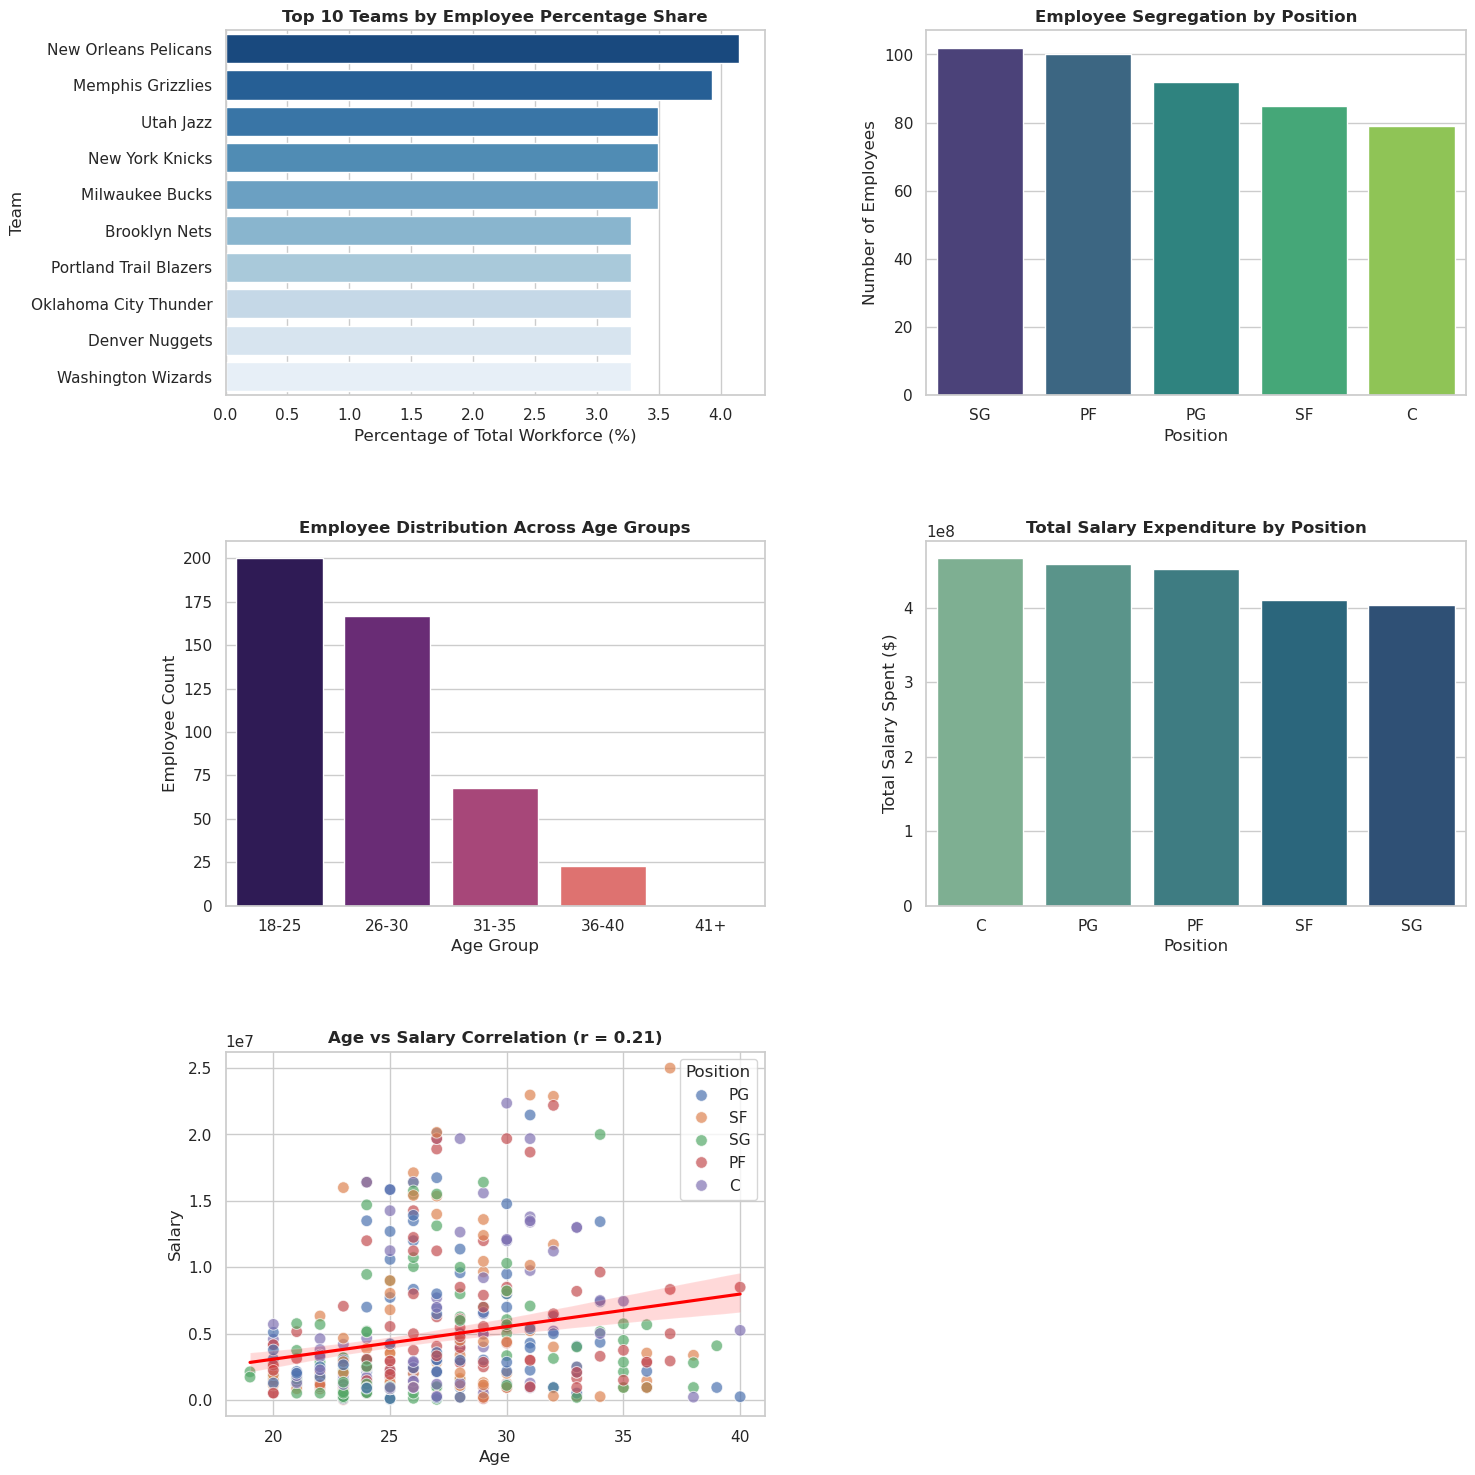

In [9]:
#Visualizations 

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.barplot(
    data=team_dist.head(10), 
    x='Percentage', 
    y='Team', 
    hue='Team', 
    legend=False, 
    ax=axes[0,0], 
    palette='Blues_r'
)
axes[0,0].set_title('Top 10 Teams by Employee Percentage Share', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Percentage of Total Workforce (%)')

#Position Breakdown
sns.barplot(
    data=pos_dist, 
    x='Position', 
    y='Employee_Count', 
    hue='Position', 
    legend=False, 
    ax=axes[0,1], 
    palette='viridis'
)
axes[0,1].set_title('Employee Segregation by Position', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Number of Employees')

#Age Distribution
sns.barplot(
    data=age_dist, 
    x='Age_Group', 
    y='Employee_Count', 
    hue='Age_Group', 
    legend=False, 
    ax=axes[1,0], 
    palette='magma'
)
axes[1,0].set_title('Employee Distribution Across Age Groups', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Employee Count')

#Salary Expenditure by Position
sns.barplot(
    data=pos_salary, 
    x='Position', 
    y='Salary', 
    hue='Position', 
    legend=False, 
    ax=axes[1,1], 
    palette='crest'
)
axes[1,1].set_title('Total Salary Expenditure by Position', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Total Salary Spent ($)')

#Age vs Salary Scatter plot
sns.scatterplot(data=df, x='Age', y='Salary', hue='Position', ax=axes[2,0], alpha=0.7, s=70)
sns.regplot(data=df, x='Age', y='Salary', scatter=False, ax=axes[2,0], color='red')
axes[2,0].set_title(f'Age vs Salary Correlation (r = {age_salary_corr:.2f})', fontsize=12, fontweight='bold')

fig.delaxes(axes[2,1])
plt.show()